<a href="https://colab.research.google.com/github/cantika-alff/2025_PBO_TI1B/blob/main/Jobsheet_AI8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LATIHAN

## 1. Decision Tree

In [ ]:
import pandas as pd

# Membaca file iris.csv
iris = pd.read_csv('Iris.csv')

# Melihat informasi dataset
iris.info()

# melihat informasi dataset pada 5 baris pertama
iris.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# menghilangkan kolom yang tidak penting
iris.drop('Id',axis=1,inplace=True)


In [ ]:
# memisahkan atribut dan label
X = iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm' ]]
y = iris['Species']

# Membagi dataset menjadi data latih & data uji
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=123)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# membuat model Decision Tree
tree_model = DecisionTreeClassifier()

# Melatih model dengan menggunakan data latih
tree_model = tree_model.fit(X_train, y_train)


In [ ]:
# Evaluasi Model
from sklearn.metrics import accuracy_score

y_pred = tree_model.predict(X_test)

acc_secore = round(accuracy_score(y_pred, y_test), 3)

print('Accuracy: ', acc_secore)


Accuracy:  0.933


In [ ]:
# prediksi model dengan tree_model.predict([[SepalLength, SepalWidth, PetalLength, PetalWidth]])
print(tree_model.predict([[6.2, 3.4, 5.4, 2.3]])[0])


Iris-virginica


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.tree import export_graphviz
export_graphviz(
    tree_model,
    out_file = "iris_tree.dot",
    feature_names = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'],
    class_names = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica' ],
    rounded= True,
    filled =True)


## 2. Linear Regression

In [ ]:
import numpy as np

#buat data jumlah kamar
bedrooms = np.array([1,1,2,2,3,4,4,5,5,5])

#data harga rumah. asumsi dalam dollar
house_price = np.array([15000, 18000, 27000, 34000, 50000, 68000, 65000, 81000,85000, 90000])


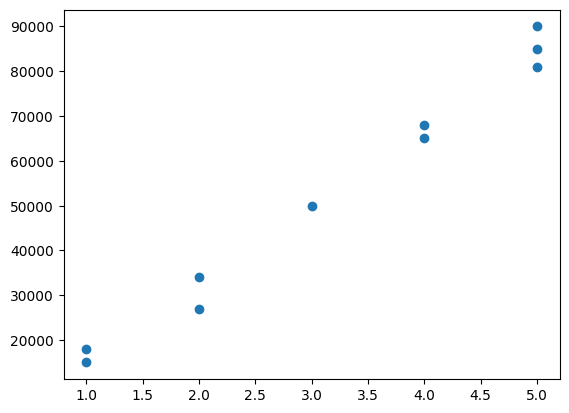

In [ ]:
# menampilkan scatter plot dari dataset
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(bedrooms, house_price)


In [ ]:
from sklearn.linear_model import LinearRegression

# latih model dengan Linear Regression.fit()
bedrooms = bedrooms.reshape(-1, 1)
linreg = LinearRegression()
linreg.fit(bedrooms, house_price)


LinearRegression()

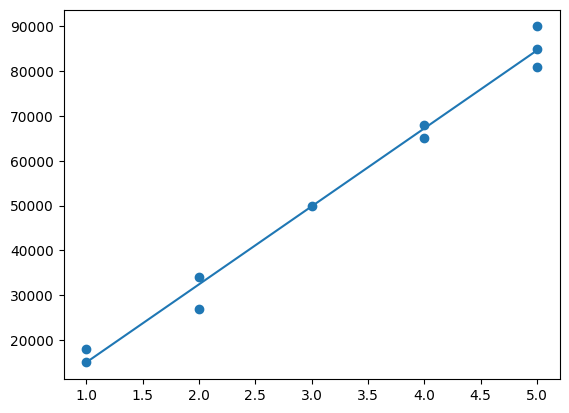

In [ ]:
# menampilkan plot hubungan antara jumlah kamar dengan harga rumah
plt.scatter(bedrooms, house_price)
plt.plot(bedrooms, linreg.predict(bedrooms))


In [ ]:
# Data testing
# Jumlah kamar yang ingin diprediksi harganya
X_test = np.array([[6], [7]])

# Melakukan prediksi harga kamar
y_pred = linreg.predict(X_test)

# Menampilkan hasil prediksi
for i in range(len(X_test)):
    print("Jumlah kamar:", X_test[i][0])
    print("Prediksi harga kamar:", y_pred[i])
    print()


Jumlah kamar: 6
Prediksi harga kamar: 102110.16949152542

Jumlah kamar: 7
Prediksi harga kamar: 119542.37288135593



In [ ]:
# uji akurasi model
linreg.score(X_test, y_pred)


1.0

## 3. Logistic Regression

In [ ]:
import pandas as pd

# membaca dataset dan mengubahnya menjadi dataframe
df = pd.read_csv('Social_Network_Ads.csv')


In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
# drop kolom yang tidak diperlukan
data = df.drop(columns=['User ID'])

# jalankan proses one-hot encoding dengan pd.get_dummies()
data = pd.get_dummies(data)
data


,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
0,19,19000,0,False,True
1,35,20000,0,False,True
2,26,43000,0,True,False
3,27,57000,0,True,False
4,19,76000,0,False,True
...,...,...,...,...,...
395,46,41000,1,True,False
396,51,23000,1,False,True
397,50,20000,1,True,False
398,36,33000,0,False,True


In [ ]:
# pisahkan atribut dan label
predictions = ['Age' , 'EstimatedSalary' , 'Gender_Female' , 'Gender_Male']
X = data[predictions]
y = data['Purchased']


In [ ]:
# lakukan normalisasi terhadap data yang kita miliki
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
scaled_data = scaler.transform(X)
scaled_data = pd.DataFrame(scaled_data, columns= X.columns)
scaled_data.head()


,Age,EstimatedSalary,Gender_Female,Gender_Male
0,-1.781797,-1.490046,-1.020204,1.020204
1,-0.253587,-1.460681,-1.020204,1.020204
2,-1.113206,-0.785290,0.980196,-0.980196
3,-1.017692,-0.374182,0.980196,-0.980196
4,-1.781797,0.183751,-1.020204,1.020204


In [ ]:
from sklearn.model_selection import train_test_split

# bagi data menjadi train dan test untuk setiap atribut dan label
X_train, X_test, y_train, y_test = train_test_split(scaled_data, y, test_size=0.2, random_state=1)


In [ ]:
from sklearn import linear_model

# latih model dengan fungsi fit
model = linear_model.LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [ ]:
# uji akurasi model
model.score(X_test, y_test)


0.825

# TUGAS

# Tugas 1

### kode 1

In [ ]:
import pandas as pd
df = pd.read_csv("iklan_sosmed.csv")

df.info()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 1 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   ID;Jenis_Kelamin;Umur;Gaji;Transaksi  400 non-null    object
dtypes: object(1)
memory usage: 3.3+ KB


In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
tree_accuracy = tree_model.score(X_test, y_test)
print("Decision Tree Accuracy:", tree_accuracy)


Decision Tree Accuracy: 0.8375


In [ ]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
logreg_accuracy = logreg.score(X_test, y_test)
print("Logistic Regression Accuracy:", logreg_accuracy)


Logistic Regression Accuracy: 0.8875


In [ ]:
if tree_accuracy > logreg_accuracy:
    print("Decision Tree is more accurate.")
else:
    print("Logistic Regression is more accurate.")


Logistic Regression is more accurate.


### kode 2

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Membaca file CSV
df = pd.read_csv("iklan_sosmed.csv", delimiter=';')

# Menampilkan informasi awal
print(df.info())
print(df.head())

# Menghapus kolom ID
df.drop('ID', axis=1, inplace=True)

# Encode kolom Jenis_Kelamin: Pria = 1, Wanita = 0
df['Jenis_Kelamin'] = df['Jenis_Kelamin'].map({'Pria': 1, 'Wanita': 0})

# Memisahkan fitur dan label
X = df[['Jenis_Kelamin', 'Umur', 'Gaji']]
y = df['Transaksi']

# Membagi data menjadi data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Membuat model Decision Tree
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

# Prediksi dan evaluasi akurasi
y_pred = tree_model.predict(X_test)
acc_score = round(accuracy_score(y_test, y_pred), 3)

print('Akurasi Decision Tree:', acc_score)

# Contoh prediksi
# Format input: [Jenis_Kelamin, Umur, Gaji]
print(tree_model.predict([[1, 30, 700000000]])[0])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             400 non-null    int64 
 1   Jenis_Kelamin  400 non-null    object
 2   Umur           400 non-null    int64 
 3   Gaji           400 non-null    int64 
 4   Transaksi      400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None
         ID Jenis_Kelamin  Umur        Gaji  Transaksi
0  15624510          Pria    19   285000000          0
1  15810944          Pria    35   300000000          0
2  15668575        Wanita    26   645000000          0
3  15603246        Wanita    27   855000000          0
4  15804002          Pria    19  1140000000          0
Akurasi Decision Tree: 0.863
0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [36]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Membaca file CSV
df = pd.read_csv("iklan_sosmed.csv", delimiter=';')

# Encode dan bersihkan data
df.drop('ID', axis=1, inplace=True)
df['Jenis_Kelamin'] = df['Jenis_Kelamin'].map({'Pria': 1, 'Wanita': 0})

# Fitur dan label
X = df[['Jenis_Kelamin', 'Umur', 'Gaji']]
y = df['Transaksi']

# Split data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Buat dan latih model Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Prediksi dan evaluasi
y_pred = log_model.predict(X_test)
acc_score = round(accuracy_score(y_test, y_pred), 3)

print("Akurasi Logistic Regression:", acc_score)

# Contoh prediksi
# Format input: [Jenis_Kelamin, Umur, Gaji]
print(log_model.predict([[0, 25, 500000000]])[0])


Akurasi Logistic Regression: 0.625
0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Tugas 2

   Tahun_Pengalaman       Gaji
0               1.1  590145000
1               1.3  693075000
2               1.5  565965000
3               2.0  652875000
4               2.2  598365000
Index(['Tahun_Pengalaman', 'Gaji'], dtype='object')
Skor akurasi (R^2): 0.7616681465472097
Koefisien: 139994171.06989083
Intercept: 384148469.97532237


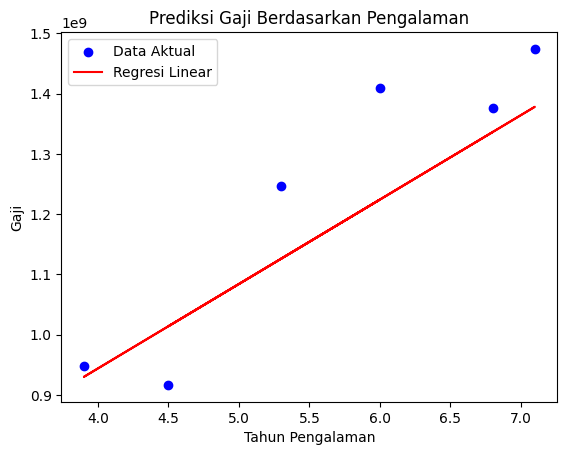

Tahun pengalaman: 5 -> Prediksi Gaji: Rp 1,084,119,325
Tahun pengalaman: 10 -> Prediksi Gaji: Rp 1,784,090,180
Tahun pengalaman: 15 -> Prediksi Gaji: Rp 2,484,061,036


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [41]:
import pandas as pd

# Membaca dataset dengan delimiter ;
df = pd.read_csv('Data_Gaji.csv', delimiter=';')

# Cek isi dan kolom
print(df.head())
print(df.columns)

# Misalkan kolom yang digunakan: Tahun_Pengalaman dan Gaji
X = df[['Tahun_Pengalaman']]
y = df['Gaji']

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Membagi data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Melatih model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluasi model
print("Skor akurasi (R^2):", model.score(X_test, y_test))
print("Koefisien:", model.coef_[0])
print("Intercept:", model.intercept_)

# Visualisasi
plt.scatter(X_test, y_test, color='blue', label='Data Aktual')
plt.plot(X_test, model.predict(X_test), color='red', label='Regresi Linear')
plt.xlabel('Tahun Pengalaman')
plt.ylabel('Gaji')
plt.title('Prediksi Gaji Berdasarkan Pengalaman')
plt.legend()
plt.show()

# Contoh prediksi gaji
tahun_baru = [[5], [10], [15]]
gaji_prediksi = model.predict(tahun_baru)

for i, tahun in enumerate(tahun_baru):
    print(f"Tahun pengalaman: {tahun[0]} -> Prediksi Gaji: Rp {int(gaji_prediksi[i]):,}")


In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Membaca dataset
df = pd.read_csv("iklan_sosmed.csv")

# Pisahkan kolom jika masih gabung dengan tanda ';'
df_split = df.iloc[:, 0].str.split(';', expand=True)
df_split.columns = ['ID', 'Jenis_Kelamin', 'Umur', 'Gaji', 'Transaksi']

# Konversi tipe data
df_split['Umur'] = df_split['Umur'].astype(int)
df_split['Gaji'] = df_split['Gaji'].astype(int)
df_split['Transaksi'] = df_split['Transaksi'].astype(int)

# Label encoding untuk Jenis Kelamin
le = LabelEncoder()
df_split['Jenis_Kelamin'] = le.fit_transform(df_split['Jenis_Kelamin'])  # Laki-Laki: 1, Perempuan: 0

# Fitur dan label
X = df_split[['Jenis_Kelamin', 'Umur', 'Gaji']]
y = df_split['Transaksi']

# Split data latih & uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# === Model Decision Tree ===
dt_model = DecisionTreeClassifier(random_state=1)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Akurasi Decision Tree:", round(acc_dt, 3))

# === Model Logistic Regression ===
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Akurasi Logistic Regression:", round(acc_lr, 3))

# === Hyperparameter Tuning Decision Tree ===
param_tree = {
    'max_depth': [2, 3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=1), param_tree, cv=5)
grid_tree.fit(X_train, y_train)
print("\nBest Score DT (Tuned):", round(grid_tree.best_score_, 3))
print("Best Params DT:", grid_tree.best_params_)

# === Hyperparameter Tuning Logistic Regression ===
param_logreg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}
grid_logreg = GridSearchCV(LogisticRegression(max_iter=1000, random_state=1), param_logreg, cv=5)
grid_logreg.fit(X_train, y_train)
print("\nBest Score LR (Tuned):", round(grid_logreg.best_score_, 3))
print("Best Params LR:", grid_logreg.best_params_)


Akurasi Decision Tree: 0.787
Akurasi Logistic Regression: 0.6

Best Score DT (Tuned): 0.922
Best Params DT: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2}

Best Score LR (Tuned): 0.653
Best Params LR: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
